## Semantic Recommendation System for Science Fiction Movies

Build a semantic search engine for science fiction movies in 5 minutes. After you set it up, you will ask the engine about an impending alien threat. Your creation will recommend books as preparation for a potential space attack.


In [2]:
!poetry add sentence-transformers transformers qdrant-client llama-index-core llama-index-embeddings-huggingface 

The following packages are already present in the pyproject.toml and will be skipped:

  - qdrant-client

If you want to update it to the latest compatible version, you can use `poetry update package`.
If you prefer to upgrade it to the latest available version, you can use `poetry add package@latest`.

Using version ^5.5.1 for sentence-transformers
Using version ^5.9.0 for transformers
Using version ^0.14.22 for llama-index-core
Using version ^0.7.0 for llama-index-embeddings-huggingface

Updating dependencies
Resolving dependencies... (4.9s)Resolving dependencies... (1.7s)

Package operations: 65 installs, 0 updates, 0 removals

  - Installing mdurl (0.1.2): Pending...
  - Installing mdurl (0.1.2): Installing...
  - Installing mdurl (0.1.2)
  - Installing markdown-it-py (4.2.0): Pending...
  - Installing markdown-it-py (4.2.0): Downloading... 0%
  - Installing markdown-it-py (4.2.0): Downloading... 100%
  - Installing markdown-it-py (4.2.0): Installing...
  - Installing markdown-it-p

In [ ]:
# from sentence_transformers import SentenceTransformer

/Users/andreicristea/personal/qdrant/essentials/day_zero/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Parsing and quering movies


We will use **TMDb** and **Wikipedia** for getting movies for the dataset. This will be closer to the real life usecases

In [24]:
import os
from typing import Any
import json
from urllib.parse import urlencode
from pydantic import BaseModel, Field
import requests
import wikipediaapi


class RawMovie(BaseModel):
    adult: bool 
    backdrop_path: str
    id: int | str
    original_language: str
    original_title: str
    overview: str
    popularity: float
    poster_path: str
    release_date: str
    title: str
    video: bool
    vote_average: float
    vote_count: float
    plot: str | None = Field(default=None)

class URLBuilder:
    def __init__(self, base_url: str) -> None:
        self._base_url = base_url
        self._params: dict[str, Any] = {}

    def add_param(self, key: str, value: Any) -> 'URLBuilder':
        """Add a single parameter"""
        self._params[key] = value
        return self
    
    def remove_param(self, key: str, value: Any) -> 'URLBuilder':
        """Remove a single parameter"""
        self._params.pop(key, None)
        return self
    
    def build(self) -> str:
        """Build the final URL"""
        if not self._params:
            return self._base_url

        encoded_params = {}
        for key, value in self._params.items():
            if isinstance(value, bool):
                encoded_params[key] = str(value).lower()
            elif isinstance(value, list):
                encoded_params[key] = [
                    str(v).lower() if isinstance(v, bool) else str(v) 
                    for v in value
                ]
            elif isinstance(value, dict):
                encoded_params[key] = json.dumps(value, ensure_ascii=False)
            elif value is not None:
                encoded_params[key] = str(value)
            
        query_str = urlencode(encoded_params, doseq=True)
        separator = '&' if '?' in self._base_url else '?'
        return f'{self._base_url}{separator}{query_str}'

    


class MoviesDataset:
    _URL = 'https://api.themoviedb.org/3'
    def __init__(self, api_key_name: str) -> None:
        self.url = MoviesDataset._URL
        api_key = os.getenv(api_key_name) 

        if api_key is None:
            raise ValueError("Please provider correct name of the env for the api_key")

        self._api_key = api_key
        self._wikipedia = wikipediaapi.Wikipedia("MovieSearch/1.0", "en")


    def get_movies(self, page: int = 1, size: int = 20):
        url_builder = (URLBuilder(f'{self.url}/discover/movie')
            .add_param('include_adult', False)
            .add_param('include_video', False)
            .add_param('language', 'en-US')
            .add_param('sort_by', 'popularity.desc')
        )
        current_page = page
        headers = {
            'accept': 'application/json',
            'Authorization': f'Bearer {self._api_key}'
        }
        movies: list[RawMovie] = []
        while size > 0:
            url = (url_builder
                .add_param('page', current_page)
                .build()
            )
            response = requests.get(url, headers=headers)
            res_json = response.json()
            raw_movies = res_json['results']
            for movie in raw_movies:
                movies.append(RawMovie(**movie))
            size -= 20
            current_page += 1 

        return movies

    def get_enhanced_movies(self):
        movies = self.get_movies()
        for movie in movies:
            page = self._wikipedia.page(movie.title)
            plot_section = page.section_by_title("Plot")
            if plot_section:
                text = plot_section.text 
                movie.plot = text
        return movies



In [26]:
movies_dataset = MoviesDataset('MOVIES_API')

movies = movies_dataset.get_enhanced_movies()

In [31]:
movies[0].poster_path

'/1q308iixueCU4pFtSYugNOevtNx.jpg'

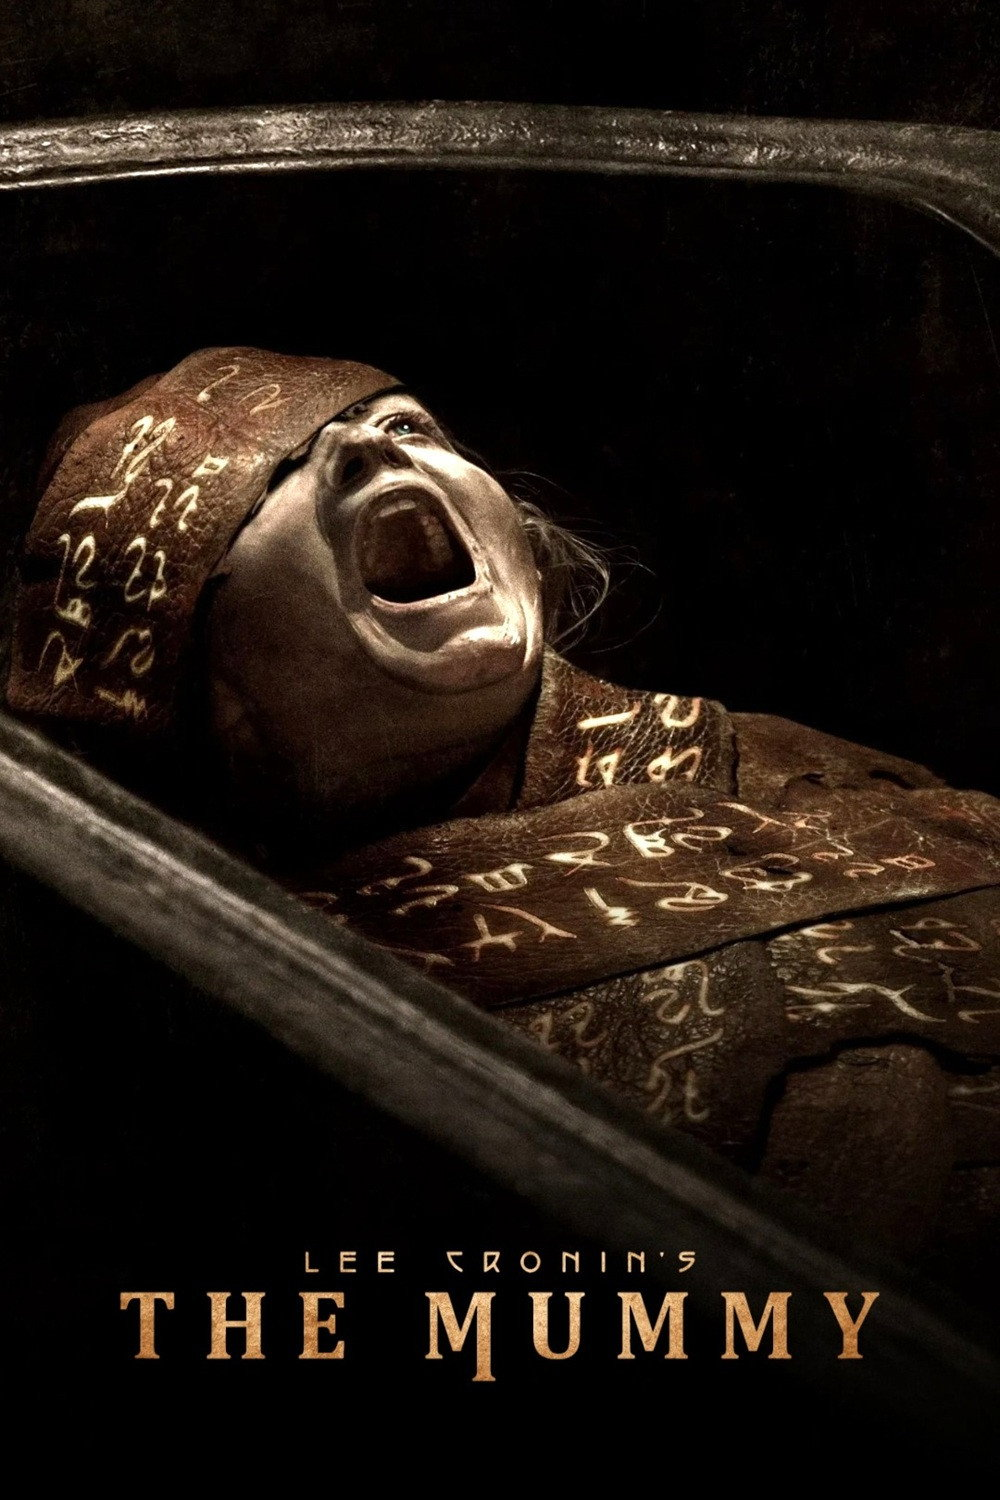

In [35]:
from IPython.display import Image, display

Image(f'https://image.tmdb.org/t/p/original/{movies[0].poster_path}', width=300)

## Step 2: The Three Vector Experiment

In [1]:
from qdrant_client import models
from sentence_transformers import SentenceTransformer


encoders = {
    'fixed': SentenceTransformer('all-MiniLM-L6-v2') ,
    'sentence': SentenceTransformer("BAAI/bge-base-en-v1.5"),
    'semantic': SentenceTransformer("BAAI/bge-base-en-v1.5"),
    'poster': SentenceTransformer("clip-ViT-B-32"),
}


vector_configs = {
    'fixed': models.VectorParams(size=384, distance=models.Distance.COSINE),
    'sentence': models.VectorParams(size=768, distance=models.Distance.COSINE),
    'semantic': models.VectorParams(size=768, distance=models.Distance.COSINE),
    'poster': models.VectorParams(size=512, distance=models.Distance.COSINE),
}

/Users/andreicristea/personal/qdrant/essentials/day_zero/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 6403.22it/s]


In [2]:
import regex as re
import numpy as np

def fixed_size_chunks(text: str, chunk_size: int = 100, overlap_percent: float = 0.15):
    """
    Split the worlds into chunks 
    """
    words = text.split()
    chunks: list[str]= []

    overlap = int(chunk_size * overlap_percent)

    for i in range(0, len(words), chunk_size - overlap):
        chunk_words = words[i:i+chunk_size]
        if chunk_words:
            chunks.append(' '.join(chunk_words))
    
    return chunks

def sentence_chunks(text: str, max_sentences = 3) -> list[str]:
    """
    Split the sentences into chunks
    """
    sentences: list[str] = re.split(r'[.?!]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    chunks = []

    for i in range(0, len(sentences), max_sentences):
        chunk_sentences = sentences[i:i + max_sentences]
        if chunk_sentences:
            chunks.append('. '.join(chunk_sentences))

    return chunks

def semantic_chunks(text: str, similarity_threshold = 0.5) -> list[str]:
    model = SentenceTransformer('all-MiniLM-L6-v2')
    sentences: list[str] = re.split(r'[.]+', text)
    embeddings = model.encode(sentences)

    chunks = []
    current_chunk: list[str] = [sentences[0]]

    for i in range(1, len(sentences)):
        similarity = np.dot(embeddings[i - 1], embeddings[i]) / (
            np.linalg.norm(embeddings[i-1]) * np.linalg.norm(embeddings[i])
        )

        if similarity < similarity_threshold: 
            chunks.append('. '.join(current_chunk))
            current_chunk = [sentences[i]]
        else:
            current_chunk.append(sentences[i])

    chunks.append('. '.join(current_chunk))
    return chunks

In [3]:
collection_name = 'movie_recommendation'

In [ ]:
from qdrant_client import QdrantClient, models

URL = os.getenv('QDRANT_URL')
API_KEY = os.getenv('QDRANT_API_KEY')

if URL is None or API_KEY is None:
    raise RuntimeError("Cannot run application w/o url and api_key of qdrant")

client= QdrantClient(
    url=URL,
    api_key=API_KEY
)

client

In [62]:
client.delete_collection(collection_name)

True

In [63]:
has_been_created = client.create_collection(
    collection_name=collection_name,
    vectors_config=vector_configs
)

has_been_created

True

In [64]:
from io import BytesIO
from PIL import Image

def load_image_from_url(url: str):
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        return Image.open(BytesIO(response.content))
    except Exception as ex:
        print("Could not use image due to: ", ex)


In [65]:
client.create_payload_index(
    collection_name=collection_name,
    field_name="chunk_strategy",
    field_schema=models.PayloadSchemaType.KEYWORD,
)

UpdateResult(operation_id=2, status=<UpdateStatus.COMPLETED: 'completed'>)

In [6]:
points: list[models.PointStruct] = []

point_id = 0

for item in movies:
    plot = item.plot if item.plot else item.overview
    image_vector: None | list[Any] = None
    image_path = f'https://image.tmdb.org/t/p/original/{item.poster_path}'
    image = load_image_from_url(image_path)
    if image:
        image_vector = encoders['poster'].encode(image).tolist()
    
    strategies = {
        'fixed': fixed_size_chunks(plot),
        'sentence': sentence_chunks(plot),
        'semantic': semantic_chunks(plot),
    }

    for strategy_name, chunks in strategies.items():
        for chunk_idx, chunk in enumerate(chunks):
            vectors: dict[Any, Any]= {
                  strategy_name: encoders[strategy_name].encode(chunk).tolist()
            }

            if image_vector:
                vectors['poster'] = image_vector
            
            points.append(
                models.PointStruct(
                    id=point_id,
                    vector=vectors,
                    payload={
                        **item.model_dump(),  # Include all original metadata
                        "chunk": chunk,
                        "chunk_strategy": strategy_name,
                        "chunk_index": chunk_idx,
                        "has_image": image_vector is not None,
                        "last_key": image_path
                    }
                )
            )

            point_id += 1

points

NameError: name 'movies' is not defined

In [79]:
len(points)

467

In [80]:
len(movies)

20

In [81]:
client.upload_points(collection_name=collection_name, points=points, wait=True)

print(f"Uploaded {len(points)} points")

Uploaded 467 points


In [7]:
import statistics

def average_score(scores: list[models.ScoredPoint]) -> float:
    """Calculate average score"""
    if not scores:  # Handle empty results
        return 0.0
    return statistics.mean([point.score for point in scores])

def search_results(query: str, image_query: str | None = None, weights = { 'image': 0.3, 'text': 0.7 }):
    """Search using one of the batch strategy + image query if provided"""
    print(f"Check search for the query: {query}")

    strategies = ['fixed', 'sentence', 'semantic']
    text_scores: dict[str, float] = {}
    text_results: dict[str, Any] = {}

    for strategy in strategies:
        result = client.query_points(
            collection_name=collection_name,
            query=encoders[strategy].encode(query).tolist(),
            using=strategy,
            with_payload=True,
            limit=20
        )

        text_scores[strategy] = average_score(result.points)

        print(f'--- {strategy.upper()} CHUNKING ---')

        if not result.points:
            print("   No results found")
            print()
            continue

        for i, point in enumerate(result.points):
            if point.payload is None:
                raise ValueError(f"Payload should exist for the {point}")
            print(f'{i}. {point.payload["title"]}')
            print(f"   Score: {point.score:.3f}")
            print(f"   Overview: {point.payload["chunk"][:80]}...")
            print()

        text_results[strategy] = result.points

    if not text_scores:  # No results found for any strategy
        print("No results found for any strategy")
        return []

    best_strategy = max(text_scores.items(), key=lambda item: item[1])
    print(f"Best text strategy is {best_strategy}")
    best_results = text_results[best_strategy[0]]

    if image_query:
        image_vector = encoders['poster'].encode(image_query).tolist()
        movie_ids = set()
        for result in best_results:
            movie_ids.add(result.payload.get('id'))

        image_scores = client.query_points(
            collection_name=collection_name,
            query=image_vector,
            using='poster', 
            query_filter=models.Filter(
                must=[
                    models.HasIdCondition(has_id=list(movie_ids))
                ]
            )
        )

        final_scores = {}

        for point in best_results:
            text_score = point.score
            image_score = next((p.score for p in image_scores.points if p.id == point.id), 0)

            # Initialize dictionary entry properly
            final_scores[point.id] = {
                'point': point,
                'score': weights['image'] * image_score + weights['text'] * text_score
            }

        return sorted(final_scores.items(), key=lambda x: x[1]['score'], reverse=True)

    return best_results  # Return text-only results if no image query

In [90]:
for i, movie in enumerate(movies[:10]):
    print(f"{i}. {movie.title}")

0. Lee Cronin's The Mummy
1. Obsession
2. Tom Clancy's Jack Ryan: Ghost War
3. Kara
4. The Punisher: One Last Kill
5. Project Hail Mary
6. Backrooms
7. The Super Mario Galaxy Movie
8. Dhurandhar: The Revenge
9. Swapped


In [8]:
def search_result(query: str, image_query: str | None = None, weights = { 'image': 0.3, 'text': 0.7 }):
    result = search_results(query, image_query, weights)[0]
    return result[1] if isinstance(result, tuple) else result

In [24]:
query = 'action and guns'

result = search_result(query)

Check search for the query: action and guns
--- FIXED CHUNKING ---
0. The Punisher: One Last Kill
   Score: 0.298
   Overview: that he still has work to do as the Punisher. Castle returns to the streets with...

1. Tom Clancy's Jack Ryan: Ghost War
   Score: 0.239
   Overview: Jack Ryan is reluctantly pulled back into espionage when an international covert...

2. The Mandalorian and Grogu
   Score: 0.239
   Overview: gunrunner. At night, Mando is attacked and captured by bounty hunter Embo, who d...

3. Dhurandhar: The Revenge
   Score: 0.226
   Overview: an imprisoned Atif Ahmed is assassinated by unknown gunmen, shocking Major Iqbal...

4. Over Your Dead Body
   Score: 0.222
   Overview: A dysfunctional couple head to a remote cabin to "reconnect", but each has secre...

5. The Shadow's Edge
   Score: 0.215
   Overview: That night, an attempt on their lives by Xi Wang fails, leading them to suspect ...

6. Kara
   Score: 0.211
   Overview: A thief tries to go straight, but when preda

In [25]:
result

ScoredPoint(id=76, version=12, score=0.59060395, payload={'adult': False, 'backdrop_path': '/qO55CD8tgVL1T4WKn6zYFFiD6lL.jpg', 'id': 1439930, 'original_language': 'en', 'original_title': 'The Punisher: One Last Kill', 'overview': 'As Frank Castle searches for meaning beyond revenge, an unexpected force pulls him back into the fight.', 'popularity': 290.8763, 'poster_path': '/qQclTgLMDvGBuUBFGHRipxkEwWR.jpg', 'release_date': '2026-05-12', 'title': 'The Punisher: One Last Kill', 'video': False, 'vote_average': 8.371, 'vote_count': 1389.0, 'plot': "Frank Castle, as the brutal vigilante known as the Punisher, kills members of the Gnucci Crime Family who are believed to be the last criminals involved in the deaths of his family. The Gnucci's former territory in New York City's Little Sicily neighborhood becomes overrun with crime. Castle lives in a Little Sicily apartment complex where he is haunted by hallucinations of people from his past. After locking up his Punisher gear, Castle goes t

In [26]:
import textwrap
from IPython.display import display, Image as IPImage

def visualize_movie_result(point: models.ScoredPoint | dict[str, Any], query: str):
    """Print a movie search result with nice formatting and render the poster."""
    movie = point.payload if isinstance(point, models.ScoredPoint) else point['point'].payload
    if movie is None:
        return

    score = point.score if isinstance(point, models.ScoredPoint) else point['score']
    width = 72
    rule = "─" * width

    def score_line(label, s):
        if s > 0.7:
            marker = "🟢"
        elif s > 0.5:
            marker = "🟡"
        else:
            marker = "🔴"
        filled = int(round(s * 20))
        bar = "█" * filled + "░" * (20 - filled)
        return f"  {marker} {label:<16} {bar} {s:.3f}"

    # Render the poster image
    try:
        display(IPImage(url=movie['last_key'], width=220))
    except Exception:
        print("[ No poster image available ]\n")

    # Header
    print(f"Search Query: {query}")
    print()
    print(rule)
    print(movie['title'].center(width))
    print(rule)
    print(f"📅 Release Date : {movie['release_date']}")
    print(f"⭐ Rating       : {movie['vote_average']}/10")
    print()

    # Overview
    print("📝 Overview")
    print(textwrap.fill(movie['overview'], width=width,
                        initial_indent="  ", subsequent_indent="  "))
    print()

    # Matching chunk
    print("🔍 Matching Chunk")
    print(textwrap.fill(f'"{movie["chunk"]}"', width=width,
                        initial_indent="  ", subsequent_indent="  "))
    print()

    # Scores
    print("🎯 Search Scores")
    print(score_line("Text Match", point.score if isinstance(point, models.ScoredPoint) else point['point'].score))
    print(score_line("Combined Score", score))
    print(f"  • Strategy : {movie['chunk_strategy']}")
    print(f"  • Chunk    : #{movie['chunk_index'] + 1}")
    print(rule)

In [27]:
visualize_movie_result(result, query)

Search Query: action and guns

────────────────────────────────────────────────────────────────────────
                      The Punisher: One Last Kill                       
────────────────────────────────────────────────────────────────────────
📅 Release Date : 2026-05-12
⭐ Rating       : 8.371/10

📝 Overview
  As Frank Castle searches for meaning beyond revenge, an unexpected
  force pulls him back into the fight.

🔍 Matching Chunk
  "Castle decides that he still has work to do as the Punisher. Castle
  returns to the streets with a new Punisher costume and arsenal. He
  stops a group of thugs from attacking innocent people and kills their
  leader"

🎯 Search Scores
  🟡 Text Match       ████████████░░░░░░░░ 0.591
  🟡 Combined Score   ████████████░░░░░░░░ 0.591
  • Strategy : sentence
  • Chunk    : #5
────────────────────────────────────────────────────────────────────────


In [28]:
def analize_chunking_effectiveness():
    print("=== CHUNKING EFFECTIVENESS STRATEGY ===")

    print("="*40)


    for strategy in ['fixed', 'sentence', 'semantic']:
        results = client.scroll(
            collection_name=collection_name,
            scroll_filter=models.Filter(
                must=[
                    models.FieldCondition(
                        key="chunk_strategy", match=models.MatchValue(value=strategy)
                    )
                ]
            ),
            limit=100
        )
        chunks = results[0]
        
        chunk_sizes = [len((chunk.payload['chunk'] if chunk.payload else [])) for chunk in chunks]

        print(f"{strategy.upper()} STRATEGY")
        print(f"  Total chunks: {len(chunks)}")
        print(f"  Average chunk size: {sum(chunk_sizes)/len(chunk_sizes):0f} chars")
        print(f"  Size range: {max(chunk_sizes) - min(chunk_sizes):0f} chars")



In [14]:
analize_chunking_effectiveness()

=== CHUNKING EFFECTIVENESS STRATEGY ===
FIXED STRATEGY
  Total chunks: 89
  Average chunk size: 512.943820 chars
  Size range: 668.000000 chars
SENTENCE STRATEGY
  Total chunks: 100
  Average chunk size: 342.090000 chars
  Size range: 688.000000 chars
SEMANTIC STRATEGY
  Total chunks: 100
  Average chunk size: 131.570000 chars
  Size range: 417.000000 chars


In [ ]:
[(movie.title, movie.overview) for movie in movies]

[("Lee Cronin's The Mummy",
  'The young daughter of a journalist disappears into the desert without a trace—eight years later, the broken family is shocked when she is returned to them, as what should be a joyful reunion turns into a living nightmare.'),
 ('Obsession',
  'After breaking the mysterious "One Wish Willow" to win his crush\'s heart, a hopeless romantic finds himself getting exactly what he asked for but soon discovers that some desires come at a dark, sinister price.'),
 ("Tom Clancy's Jack Ryan: Ghost War",
  'Jack Ryan is reluctantly pulled back into espionage when an international covert mission unravels a deadly conspiracy. Racing against time, he joins CIA allies Mike November & James Greer and sharp MI6 officer Emma Marlowe to battle a rogue black-ops unit in a high-stakes, deeply personal fight.'),
 ('Kara',
  'A thief tries to go straight, but when predatory banks trap his father in debt, he returns to crime — with a determined cop closing in on his trail.'),
 ('T

In [29]:
queries = [
    ("computer hacker fighting machines in the future", None), # expected: Matrix
    ("Mario and Luigi fighting Bowser in space", None), # Direct match for "The Super Mario Galaxy Movie"
    ("doorway basement into hell", None), #  Tests if it finds "Backrooms" (meme-born movie)
    ("meme born movie", None), # Backrooms" (meme-born movie)
    ("bird enemies swap bodies", None), # Should match "Swapped" but quite specific
    ("anime about alchemy and transmutation circles", None), # No FMAB :(
    ("vampire romance in Victorian London", None),  # should not find exact match
    ("time travel paradox movie", None), # no timetravel this weekends
    ("action movie with fighting", None), # (Mortal Kombat, Punisher, Matrix, etc.) -> all good
    ("love story", None), #  Your Heart Will Be Broken, Chand Mera Dil, 
    ("a man sees a rabbit on a woman shoulder, and after that understands that the whole world is a lie, and computers control everything. also fight cool dudes with glasses, everything green",
    None), # overly explained Matrix
    ("movie about this character", "A person wears black leather coat, looks cool, has woman on one side with dark sunglasses") # Should match Matrix but only with visual context
]

In [31]:
result_titles = []
for query in queries:
    result = search_result(query[0], query[1])
    visualize_movie_result(result, f'text query: {query[0]}, image query: {query[1]}')
    result_titles.append(result.payload['title'] if (isinstance(result, models.ScoredPoint) and result.payload) else result['point'].payload['title'])

Check search for the query: computer hacker fighting machines in the future
--- FIXED CHUNKING ---
0. The Matrix
   Score: 0.372
   Overview: In 1999, in an unnamed city, Thomas Anderson, a computer programmer known as "Ne...

1. The Matrix
   Score: 0.339
   Overview: can kill Neo and Trinity, he is killed by Tank, a wounded crew member, who extra...

2. The Matrix
   Score: 0.337
   Overview: real world, machines called Sentinels attack the Nebuchadnezzar. Standing by Neo...

3. The Shadow's Edge
   Score: 0.285
   Overview: The Judiciary Police, led by Wang Xuemei, have been hot on the trail of a heist ...

4. The Matrix
   Score: 0.269
   Overview: and tended by machines before he is ejected from the building and rescued by Mor...

5. Dhurandhar: The Revenge
   Score: 0.247
   Overview: to remain silent for the sake of their son, Zayan, and understanding his reasons...

6. The Matrix
   Score: 0.239
   Overview: on human civilization at its peak. The remaining free humans founded a

Search Query: text query: computer hacker fighting machines in the future, image query: None

────────────────────────────────────────────────────────────────────────
                               The Matrix                               
────────────────────────────────────────────────────────────────────────
📅 Release Date : 1999-03-31
⭐ Rating       : 8.247/10

📝 Overview
  Set in the 22nd century, The Matrix tells the story of a computer
  hacker who joins a group of underground insurgents fighting the vast
  and powerful computers who now rule the earth.

🔍 Matching Chunk
  " In the real world, machines called Sentinels attack the
  Nebuchadnezzar"

🎯 Search Scores
  🟡 Text Match       ████████████░░░░░░░░ 0.613
  🟡 Combined Score   ████████████░░░░░░░░ 0.613
  • Strategy : semantic
  • Chunk    : #20
────────────────────────────────────────────────────────────────────────
Check search for the query: Mario and Luigi fighting Bowser in space
--- FIXED CHUNKING ---
0. The Super Mar

Search Query: text query: Mario and Luigi fighting Bowser in space, image query: None

────────────────────────────────────────────────────────────────────────
                      The Super Mario Galaxy Movie                      
────────────────────────────────────────────────────────────────────────
📅 Release Date : 2026-04-01
⭐ Rating       : 8.107/10

📝 Overview
  Having thwarted Bowser's previous plot to marry Princess Peach, Mario
  and Luigi now face a fresh threat in Bowser Jr., who is determined to
  liberate his father from captivity and restore the family legacy.
  Alongside companions new and old, the brothers travel across the stars
  to stop the young heir's crusade.

🔍 Matching Chunk
  " lifts Peach's castle into space in an attempt to free his father,
  but a battle with the brothers and Yoshi causes his spaceship to drop
  the castle into the Honeyhive Galaxy.  Bowser goads Mario into
  attacking him, thus unshrinking him, but kindly offers to be arrested
  for dama

Search Query: text query: doorway basement into hell, image query: None

────────────────────────────────────────────────────────────────────────
                               Backrooms                                
────────────────────────────────────────────────────────────────────────
📅 Release Date : 2026-05-27
⭐ Rating       : 6.7/10

📝 Overview
  A strange doorway appears in the basement of a furniture showroom.

🔍 Matching Chunk
  "A strange doorway appears in the basement of a furniture showroom"

🎯 Search Scores
  🟢 Text Match       ██████████████░░░░░░ 0.722
  🟢 Combined Score   ██████████████░░░░░░ 0.722
  • Strategy : sentence
  • Chunk    : #1
────────────────────────────────────────────────────────────────────────
Check search for the query: meme born movie
--- FIXED CHUNKING ---
0. Chand Mera Dil
   Score: 0.242
   Overview: Aarav and Chandni's passionate college romance is struck by adulthood far too so...

1. Lee Cronin's The Mummy
   Score: 0.241
   Overview: One m

Search Query: text query: meme born movie, image query: None

────────────────────────────────────────────────────────────────────────
                       Your Heart Will Be Broken                        
────────────────────────────────────────────────────────────────────────
📅 Release Date : 2026-03-26
⭐ Rating       : 6.762/10

📝 Overview
  High school student Polina is saved from bullying at her new school
  and makes a deal with the main bully Bars: he must pretend to be her
  boyfriend and protect her, and she must do everything he says. During
  this game, the couple develops real feelings, but her family and
  classmates have reasons to separate the lovers.

🔍 Matching Chunk
  "High school student Polina is saved from bullying at her new school
  and makes a deal with the main bully Bars: he must pretend to be her
  boyfriend and protect her, and she must do everything he says. During
  this game, the couple develops real feelings, but her family and
  classmates have reason

...

Search Query: text query: time travel paradox movie, image query: None

────────────────────────────────────────────────────────────────────────
                               The Matrix                               
────────────────────────────────────────────────────────────────────────
📅 Release Date : 1999-03-31
⭐ Rating       : 8.247/10

📝 Overview
  Set in the 22nd century, The Matrix tells the story of a computer
  hacker who joins a group of underground insurgents fighting the vast
  and powerful computers who now rule the earth.

🔍 Matching Chunk
  "Morpheus reveals that the year is approximately 2199. In the 21st
  century, humanity lost a war against its artificially intelligent
  creations, leaving Earth a devastated ruin. Humans blackened the sky
  to deprive the machines of solar power, but the machines retaliated by
  creating vast fields of artificially grown humans, harvesting their
  bioelectric energy"

🎯 Search Scores
  🟡 Text Match       ████████████░░░░░░░░ 0.591

Search Query: text query: action movie with fighting, image query: None

────────────────────────────────────────────────────────────────────────
                   Tom Clancy's Jack Ryan: Ghost War                    
────────────────────────────────────────────────────────────────────────
📅 Release Date : 2026-05-20
⭐ Rating       : 7.139/10

📝 Overview
  Jack Ryan is reluctantly pulled back into espionage when an
  international covert mission unravels a deadly conspiracy. Racing
  against time, he joins CIA allies Mike November & James Greer and
  sharp MI6 officer Emma Marlowe to battle a rogue black-ops unit in a
  high-stakes, deeply personal fight.

🔍 Matching Chunk
  "Jack Ryan is reluctantly pulled back into espionage when an
  international covert mission unravels a deadly conspiracy. Racing
  against time, he joins CIA allies Mike November & James Greer and
  sharp MI6 officer Emma Marlowe to battle a rogue black-ops unit in a
  high-stakes, deeply personal fight"

🎯 Search

Search Query: text query: love story, image query: None

────────────────────────────────────────────────────────────────────────
                         Pati Patni Aur Woh Do                          
────────────────────────────────────────────────────────────────────────
📅 Release Date : 2026-05-15
⭐ Rating       : 7.5/10

📝 Overview
  A seemingly perfect marriage in Prayagraj takes an unexpected turn
  when one decision leads to a chain of misunderstandings, suspicion,
  and comedic chaos.

🔍 Matching Chunk
  "Back home, Praja is tasked with an assignment to capture a wild wolf
  in Benaras. He visits with Nilofer and his team, and makes one final
  public appearance with Chanchal. At a family wedding, he announces
  their engagement, leading to joy from Chanchal's family"

🎯 Search Scores
  🟡 Text Match       ███████████░░░░░░░░░ 0.566
  🟡 Combined Score   ███████████░░░░░░░░░ 0.566
  • Strategy : sentence
  • Chunk    : #6
────────────────────────────────────────────────────────

Search Query: text query: a man sees a rabbit on a woman shoulder, and after that understands that the whole world is a lie, and computers control everything. also fight cool dudes with glasses, everything green, image query: None

────────────────────────────────────────────────────────────────────────
                               The Matrix                               
────────────────────────────────────────────────────────────────────────
📅 Release Date : 1999-03-31
⭐ Rating       : 8.247/10

📝 Overview
  Set in the 22nd century, The Matrix tells the story of a computer
  hacker who joins a group of underground insurgents fighting the vast
  and powerful computers who now rule the earth.

🔍 Matching Chunk
  " Morpheus and his crew hack into the Matrix to liberate others,
  exploiting its rules to gain superhuman abilities inside it"

🎯 Search Scores
  🟡 Text Match       ██████████░░░░░░░░░░ 0.507
  🟡 Combined Score   ██████████░░░░░░░░░░ 0.507
  • Strategy : semantic
  • Chunk 

Search Query: text query: movie about this character, image query: A person wears black leather coat, looks cool, has woman on one side with dark sunglasses

────────────────────────────────────────────────────────────────────────
                                Swapped                                 
────────────────────────────────────────────────────────────────────────
📅 Release Date : 2026-05-01
⭐ Rating       : 8.974/10

📝 Overview
  A small woodland creature and a majestic bird, two natural sworn
  enemies of the Valley, magically trade places and set off on an
  adventure of a lifetime to switch back. Their journey soon uncovers a
  greater threat—one that could endanger not only their species, but the
  entire valley they call home.

🔍 Matching Chunk
  "Ollie is soon rescued by the Javan who attacked him earlier, named
  Ivy, alongside her sisters Violet and Lily. Ollie soon meets an
  amiable, but absent-minded fish named Boogle who informs him of a pod
  on a nearby dead Dz

In [32]:
print(result_titles)

['The Matrix', 'The Super Mario Galaxy Movie', 'Backrooms', 'Your Heart Will Be Broken', 'Project Hail Mary', 'The Matrix', "Lee Cronin's The Mummy", 'The Matrix', "Tom Clancy's Jack Ryan: Ghost War", 'Pati Patni Aur Woh Do', 'The Matrix', 'Swapped']


[Day 1] Building a Semantic Search Engine

  High-Level Summary
  - Domain: "I built a semantic search for movie recommendations using plot descriptions"
  - Winner: "Best chunking strategy was semantic because it produced the highest quality embeddings with optimal granularity"

  Project-Specific Details
  - Collection: movie_recommendations (Cosine) with vectors: fixed/sentence/semantic chunking strategies
  - Dataset: 20 movie items with plot descriptions (snapshot: 2026-06-03)
  - Chunks: fixed=89/513 avg chars, sentence=100/342 avg chars, semantic=100/132 avg chars
  - Demo query: "Try 'computer hacker fighting machines in the future'" — it found The Matrix perfectly, plus multimodal search correctly identified character descriptions

  Surprise
  - "Most unexpected finding was that semantic chunking's smaller, focused chunks (131 chars avg) drastically outperformed larger fixed chunks (513 chars avg) - proving that preprocessing
  investment pays dividends in search quality. Also discovered that ambiguous text queries dominate image signals in multimodal search, with 'bird enemies swap bodies' hilariously matching
  Project Hail Mary instead of Swapped due to thematic sci-fi overlap."

  Next step
  - "Tomorrow I'll experiment with hybrid chunking strategies, optimize text-to-image weight ratios in multimodal scoring, and test semantic boosting for exact concept matches to reduce false
  positives like the bird-swap mismatch."